# Basic Simulation Evaluation  
**Simulation Period:** 2016-05-17 → 2016-05-30  

## Evaluation Metrics
| # | Metric | Definition |
|---|--------|------------|
| 1 | **Average Cycle Time** | Mean time to finish a process instance |
| 2 | **Average Resource Occupation** | Mean share the resources are working during their availabilities |
| 3 | **(Weighted) Resource Fairness** | Mean deviation from the average resource occupation |

Followed by **Management Question**: *"Management wants to fire two employees — which ones and what is the impact?"*

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import datetime
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

BASE = Path('..')
COLORS = {'basic': "#2870D5", 'advanced': "#DD528A"}

# Simulation period constants
SIM_START = datetime.date(2016, 5, 17)
SIM_END   = datetime.date(2016, 5, 30)
DAY_ZERO  = datetime.date(2016, 1, 1)   # DayId=0 anchor

# Only Workflow activities have explicit start/complete pairs
W_ACTIVITIES = [
    'W_Call after offers',
    'W_Call incomplete files',
    'W_Complete application',
    'W_Handle leads',
    'W_Validate application',
]

## Data Loading

In [70]:
# Event logs
basic_log    = pd.read_csv(BASE / 'decision_analysis/sim_output_basic.csv',
                           parse_dates=['time:timestamp'])
advanced_log = pd.read_csv(BASE / 'decision_analysis/sim_output_advanced.csv',
                           parse_dates=['time:timestamp'])

# Resource schedules
avail_df = pd.read_csv(BASE / 'resources/availabilities/availabilities_advanced.csv')
avail_df['StartTime']   = pd.to_datetime(avail_df['StartTime'],   format='%H:%M:%S').dt.time
avail_df['EndTime']     = pd.to_datetime(avail_df['EndTime'],     format='%H:%M:%S').dt.time
avail_df['DurationMin'] = avail_df['DurationMin'].fillna(0).astype(int)

# Role assignments
roles_df   = pd.read_csv(BASE / 'resources/permissions/resource_roles.csv')
role_perms = pd.read_csv(BASE / 'resources/permissions/role_permissions.csv')

print(f"Basic log   : {len(basic_log):>6,} events | {basic_log['case:concept:name'].nunique():>4} cases")
print(f"Advanced log: {len(advanced_log):>6,} events | {advanced_log['case:concept:name'].nunique():>4} cases")
print(f"Simulation  : {basic_log['time:timestamp'].min().date()} -> {basic_log['time:timestamp'].max().date()}")
print(f"Resources in schedule: {avail_df['Resource'].nunique()}")

Basic log   : 24,944 events | 1563 cases
Advanced log: 22,822 events | 1563 cases
Simulation  : 2016-05-17 -> 2016-05-30
Resources in schedule: 140


## Helper Functions

In [71]:
# Metric helpers
def compute_cycle_times(df):
    """Return Series of per-case cycle time in hours."""
    ct = df.groupby('case:concept:name')['time:timestamp'].agg(['min', 'max'])
    return (ct['max'] - ct['min']).dt.total_seconds() / 3600


def compute_working_seconds(df):
    """
    Compute total working seconds per resource.
    Only W_* activities carry explicit start/complete pairs;
    Application (A_*) and Offer (O_*) events are instantaneous.
    """
    w = df[df['concept:name'].isin(W_ACTIVITIES)].copy()
    starts    = (w[w['lifecycle:transition'] == 'start']
                 [['case:concept:name', 'concept:name', 'org:resource', 'time:timestamp']]
                 .rename(columns={'time:timestamp': 'start_time'}))
    completes = (w[w['lifecycle:transition'] == 'complete']
                 [['case:concept:name', 'concept:name', 'org:resource', 'time:timestamp']]
                 .rename(columns={'time:timestamp': 'end_time'}))
    merged = pd.merge(starts, completes,
                      on=['case:concept:name', 'concept:name', 'org:resource'])
    merged['working_seconds'] = (
        (merged['end_time'] - merged['start_time'])
        .dt.total_seconds()
        .clip(lower=0)
    )
    return merged.groupby('org:resource')['working_seconds'].sum()


def compute_available_seconds(avail_df, start_date=SIM_START, end_date=SIM_END):
    """
    Compute total scheduled (available) seconds per resource
    across every day in [start_date, end_date], inclusive.
    DayId is defined as (date - 2016-01-01).days % 7
    """
    result = {}
    for resource, grp in avail_df.groupby('Resource'):
        total = 0.0
        day = start_date
        while day <= end_date:
            day_id = (day - DAY_ZERO).days % 7
            row = grp[grp['DayId'] == day_id]
            if not row.empty:
                r = row.iloc[0]
                shift_s = datetime.datetime.combine(day, r['StartTime'])
                shift_e = datetime.datetime.combine(day, r['EndTime'])
                secs = max(0.0, (shift_e - shift_s).total_seconds() - r['DurationMin'] * 60)
                total += secs
            day += datetime.timedelta(days=1)
        result[resource] = total
    return pd.Series(result, name='available_seconds')


def compute_occupation(working_s, available_s):
    """Return DataFrame with working, available, and occupation columns."""
    df = pd.DataFrame({'working_seconds': working_s,
                       'available_seconds': available_s})
    df['working_seconds'] = df['working_seconds'].fillna(0)
    df = df[df['available_seconds'] > 0].copy()
    df['occupation'] = (df['working_seconds'] / df['available_seconds']).clip(0, 1)
    return df


def fairness_metrics(occ_series, avail_seconds=None):
    """
    Returns:
      mean_occ   – mean occupation
      mad        – unweighted mean absolute deviation (lower -> fairer)
      wmad       – weighted MAD (weight = available_seconds fraction)
    """
    mean_occ = occ_series.mean()
    mad = (occ_series - mean_occ).abs().mean()
    if avail_seconds is not None:
        w = avail_seconds / avail_seconds.sum()
        wmad = (w * (occ_series - mean_occ).abs()).sum()
    else:
        wmad = np.nan
    return mean_occ, mad, wmad


## Metric 1 – Average Cycle Time

**Definition:** The cycle time of a process instance is the elapsed wall-clock time from the moment the first event of that case is recorded until its last event.  
$$\overline{CT} = \frac{1}{|\mathcal{C}|} \sum_{c \in \mathcal{C}} (t^{\max}_c - t^{\min}_c)$$

A lower average cycle time means cases are completed faster -> a direct indicator of process efficiency.

In [72]:
basic_ct    = compute_cycle_times(basic_log)
advanced_ct = compute_cycle_times(advanced_log)

ct_summary = pd.DataFrame({
    'Mean (h)':   [basic_ct.mean(),   advanced_ct.mean()],
    'Median (h)': [basic_ct.median(), advanced_ct.median()],
    'Std (h)':    [basic_ct.std(),    advanced_ct.std()],
    'Min (h)':    [basic_ct.min(),    advanced_ct.min()],
    'Max (h)':    [basic_ct.max(),    advanced_ct.max()],
    'Mean (days)':[basic_ct.mean()/24, advanced_ct.mean()/24],
}, index=['Basic Router', 'Advanced Router'])

print('METRIC 1: AVERAGE CYCLE TIME')
print(ct_summary.round(2).to_string())

METRIC 1: AVERAGE CYCLE TIME
                 Mean (h)  Median (h)  Std (h)  Min (h)  Max (h)  Mean (days)
Basic Router        13.12        2.57    28.45     0.05   286.98         0.55
Advanced Router     12.73        1.92    28.61     0.00   309.78         0.53


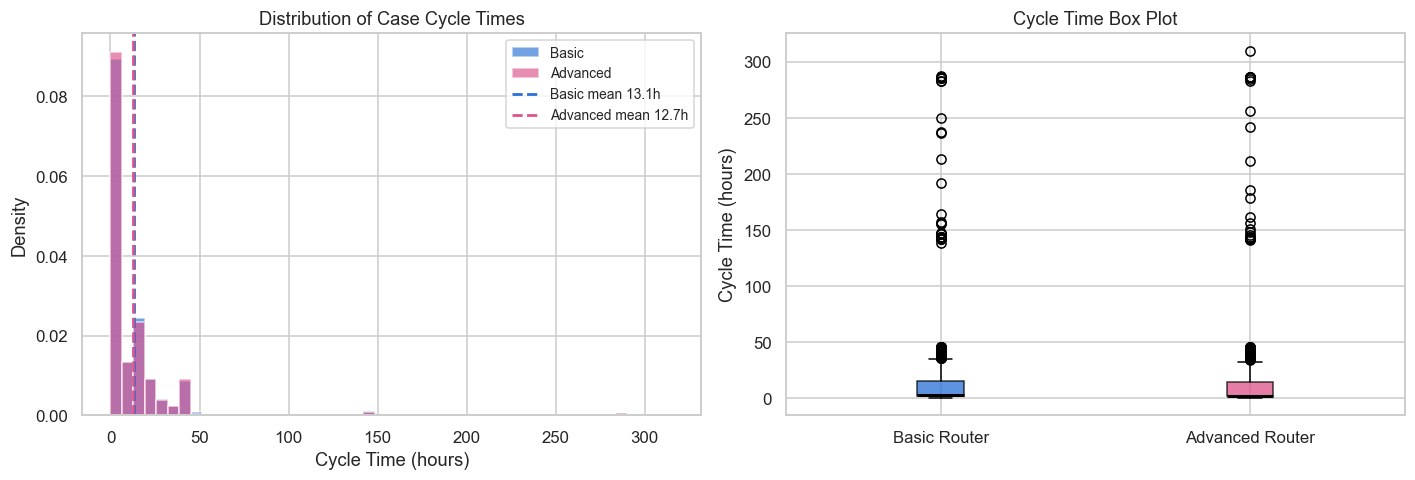

Saved -> results/metric1_cycle_time.png


In [73]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: histogram
ax = axes[0]
bins = np.linspace(0, max(basic_ct.max(), advanced_ct.max()) * 1.02, 50)
ax.hist(basic_ct,    bins=bins, alpha=0.65, color=COLORS['basic'],    label='Basic',    density=True)
ax.hist(advanced_ct, bins=bins, alpha=0.65, color=COLORS['advanced'], label='Advanced', density=True)
ax.axvline(basic_ct.mean(),    color=COLORS['basic'],    linestyle='--', lw=1.8,
           label=f'Basic mean {basic_ct.mean():.1f}h')
ax.axvline(advanced_ct.mean(), color=COLORS['advanced'], linestyle='--', lw=1.8,
           label=f'Advanced mean {advanced_ct.mean():.1f}h')
ax.set_xlabel('Cycle Time (hours)')
ax.set_ylabel('Density')
ax.set_title('Distribution of Case Cycle Times')
ax.legend(fontsize=9)

# Right: boxplot
ax2 = axes[1]
data = [basic_ct.values, advanced_ct.values]
bp = ax2.boxplot(data, patch_artist=True, notch=False,
                 medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], [COLORS['basic'], COLORS['advanced']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax2.set_xticks([1, 2])
ax2.set_xticklabels(['Basic Router', 'Advanced Router'])
ax2.set_ylabel('Cycle Time (hours)')
ax2.set_title('Cycle Time Box Plot')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'metric1_cycle_time.png', bbox_inches='tight')
plt.show()
print('Saved -> results/metric1_cycle_time.png')

## Metric 2 – Average Resource Occupation

**Definition:** For each resource $r$, occupation is the fraction of scheduled working time actually spent executing tasks:
$$\text{occ}(r) = \frac{\sum_{e\,:\,\text{resource}=r} (t^{\text{complete}}_e - t^{\text{start}}_e)}{\text{AvailableTime}(r)}$$

The **Average Resource Occupation** is the mean over all resources:  
$$\overline{\text{occ}} = \frac{1}{|\mathcal{R}|}\sum_{r \in \mathcal{R}} \text{occ}(r)$$

> **Note:** Only *Workflow* activities (`W_*`) have explicit `start` / `complete` event pairs in this simulator; Application (`A_*`) and Offer (`O_*`) events are instantaneous and do not contribute to working time.

In [74]:
# Compute working time per resource
print('Computing working time per resource...')
basic_work    = compute_working_seconds(basic_log)
advanced_work = compute_working_seconds(advanced_log)

# Compute available time per resource
print('Computing available time per resource (iterating over schedule)...')
available = compute_available_seconds(avail_df)

# Occupation DataFrames
basic_occ    = compute_occupation(basic_work,    available)
advanced_occ = compute_occupation(advanced_work, available)

# Summary
occ_summary = pd.DataFrame({
    'Mean Occupation':   [basic_occ['occupation'].mean(),   advanced_occ['occupation'].mean()],
    'Median Occupation': [basic_occ['occupation'].median(), advanced_occ['occupation'].median()],
    'Std':               [basic_occ['occupation'].std(),    advanced_occ['occupation'].std()],
    'Max':               [basic_occ['occupation'].max(),    advanced_occ['occupation'].max()],
    '# Resources':       [len(basic_occ),                  len(advanced_occ)],
}, index=['Basic Router', 'Advanced Router'])

print('\nMETRIC 2: AVERAGE RESOURCE OCCUPATION')
print((occ_summary * [100, 100, 100, 100, 1]).round(2).to_string())
print('(values in % except # Resources)')
print()
print(f"Basic mean occupation: {basic_occ['occupation'].mean()*100:.3f}%")
print(f"Advanced mean occupation: {advanced_occ['occupation'].mean()*100:.3f}%")

Computing working time per resource...
Computing available time per resource (iterating over schedule)...

METRIC 2: AVERAGE RESOURCE OCCUPATION
                 Mean Occupation  Median Occupation    Std    Max  # Resources
Basic Router               43.58              39.02  33.21  100.0          140
Advanced Router            42.40              39.99  31.67  100.0          140
(values in % except # Resources)

Basic mean occupation: 43.584%
Advanced mean occupation: 42.398%


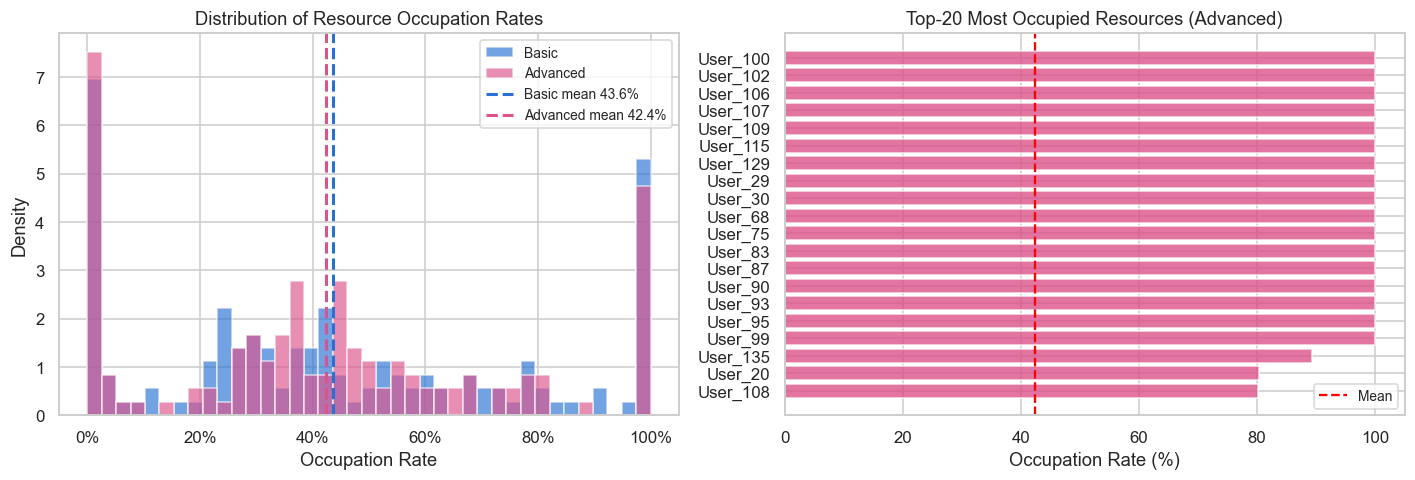

Saved -> results/metric2_resource_occupation.png


In [75]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: distribution of occupation rates
ax = axes[0]
bins = np.linspace(0, 1, 40)
ax.hist(basic_occ['occupation'],    bins=bins, alpha=0.65, color=COLORS['basic'],    label='Basic',    density=True)
ax.hist(advanced_occ['occupation'], bins=bins, alpha=0.65, color=COLORS['advanced'], label='Advanced', density=True)
ax.axvline(basic_occ['occupation'].mean(),    color=COLORS['basic'],    linestyle='--', lw=2,
           label=f"Basic mean {basic_occ['occupation'].mean()*100:.1f}%")
ax.axvline(advanced_occ['occupation'].mean(), color=COLORS['advanced'], linestyle='--', lw=2,
           label=f"Advanced mean {advanced_occ['occupation'].mean()*100:.1f}%")
ax.set_xlabel('Occupation Rate')
ax.set_ylabel('Density')
ax.set_title('Distribution of Resource Occupation Rates')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(fontsize=9)

# Right: top-20 most occupied resources (advanced)
ax2 = axes[1]
top20 = advanced_occ.nlargest(20, 'occupation')
ax2.barh(top20.index[::-1], top20['occupation'][::-1] * 100,
         color=COLORS['advanced'], alpha=0.8)
ax2.axvline(advanced_occ['occupation'].mean() * 100,
            color='red', linestyle='--', lw=1.5, label='Mean')
ax2.set_xlabel('Occupation Rate (%)')
ax2.set_title('Top-20 Most Occupied Resources (Advanced)')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'metric2_resource_occupation.png', bbox_inches='tight')
plt.show()
print('Saved -> results/metric2_resource_occupation.png')

## Metric 3 – (Weighted) Resource Fairness

**Definition:** Fairness measures how evenly the workload is spread across resources. We use the **Mean Absolute Deviation (MAD)** from the average occupation:

$$\text{Fairness}_{\text{unweighted}} = \frac{1}{|\mathcal{R}|}\sum_{r}|\text{occ}(r) - \overline{\text{occ}}|$$

**Weighted variant** — resources with longer availability periods count more:

$$\text{Fairness}_{\text{weighted}} = \sum_{r} w_r \cdot |\text{occ}(r) - \overline{\text{occ}}|, \quad w_r = \frac{\text{AvailableTime}(r)}{\sum_{r'}\text{AvailableTime}(r')}$$

**Lower = fairer** (smaller deviation = more equal load distribution).

In [76]:
# Compute fairness
b_mean, b_mad, b_wmad = fairness_metrics(
    basic_occ['occupation'], basic_occ['available_seconds'])
a_mean, a_mad, a_wmad = fairness_metrics(
    advanced_occ['occupation'], advanced_occ['available_seconds'])

fairness_summary = pd.DataFrame({
    'Mean Occupation':          [b_mean,  a_mean],
    'MAD (unweighted)':         [b_mad,   a_mad],
    'MAD (weighted)':           [b_wmad,  a_wmad],
    'Fairness Score (1-MAD)':   [1-b_mad, 1-a_mad],
}, index=['Basic Router', 'Advanced Router'])

print('METRIC 3: RESOURCE FAIRNESS')
print(fairness_summary.round(5).to_string())
print()
print('Interpretation: Lower MAD = fairer workload distribution')
print(f"  Basic unweighted MAD: {b_mad:.5f}  |  weighted MAD: {b_wmad:.5f}")
print(f"  Advanced unweighted MAD: {a_mad:.5f}  |  weighted MAD: {a_wmad:.5f}")

METRIC 3: RESOURCE FAIRNESS
                 Mean Occupation  MAD (unweighted)  MAD (weighted)  Fairness Score (1-MAD)
Basic Router             0.43584           0.27720         0.27411                 0.72280
Advanced Router          0.42398           0.25318         0.25071                 0.74682

Interpretation: Lower MAD = fairer workload distribution
  Basic unweighted MAD: 0.27720  |  weighted MAD: 0.27411
  Advanced unweighted MAD: 0.25318  |  weighted MAD: 0.25071


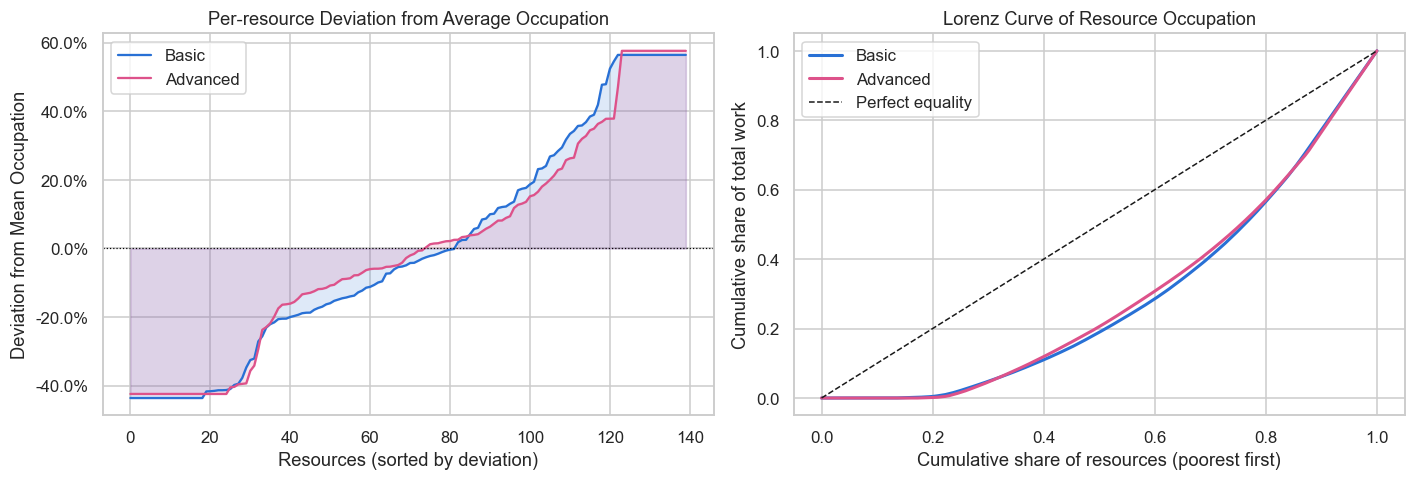

Saved -> results/metric3_resource_fairness.png


In [77]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: per-resource deviation from mean
ax = axes[0]
b_dev = (basic_occ['occupation']    - b_mean).sort_values()
a_dev = (advanced_occ['occupation'] - a_mean).sort_values()

ax.plot(range(len(b_dev)), b_dev.values,    color=COLORS['basic'],    lw=1.5, label='Basic')
ax.plot(range(len(a_dev)), a_dev.values,    color=COLORS['advanced'], lw=1.5, label='Advanced')
ax.axhline(0, color='black', lw=0.8, linestyle=':')
ax.fill_between(range(len(b_dev)), b_dev.values, 0,
                where=(b_dev.values > 0), alpha=0.15, color=COLORS['basic'])
ax.fill_between(range(len(b_dev)), b_dev.values, 0,
                where=(b_dev.values < 0), alpha=0.15, color=COLORS['basic'])
ax.fill_between(range(len(a_dev)), a_dev.values, 0,
                where=(a_dev.values > 0), alpha=0.15, color=COLORS['advanced'])
ax.fill_between(range(len(a_dev)), a_dev.values, 0,
                where=(a_dev.values < 0), alpha=0.15, color=COLORS['advanced'])
ax.set_xlabel('Resources (sorted by deviation)')
ax.set_ylabel('Deviation from Mean Occupation')
ax.set_title('Per-resource Deviation from Average Occupation')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
ax.legend()

# Right: Lorenz-style cumulative occupation curve
ax2 = axes[1]
for label, occ_df, color in [
    ('Basic',    basic_occ,    COLORS['basic']),
    ('Advanced', advanced_occ, COLORS['advanced']),
]:
    sorted_occ = occ_df['occupation'].sort_values().values
    cum = np.cumsum(sorted_occ) / sorted_occ.sum()
    x = np.linspace(0, 1, len(cum))
    ax2.plot(x, cum, color=color, lw=2, label=label)
ax2.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect equality')
ax2.set_xlabel('Cumulative share of resources (poorest first)')
ax2.set_ylabel('Cumulative share of total work')
ax2.set_title('Lorenz Curve of Resource Occupation')
ax2.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'metric3_resource_fairness.png', bbox_inches='tight')
plt.show()
print('Saved -> results/metric3_resource_fairness.png')

## Summary Dashboard – Basic vs Advanced Router

Consolidating all three metrics to directly compare routing strategies.

In [78]:
summary = pd.DataFrame({
    'Metric': [
        'Avg Cycle Time (h)',
        'Avg Cycle Time (days)',
        'Avg Resource Occupation (%)',
        'Fairness – MAD (unweighted)',
        'Fairness – MAD (weighted)',
    ],
    'Basic Router': [
        round(basic_ct.mean(), 2),
        round(basic_ct.mean() / 24, 3),
        round(basic_occ['occupation'].mean() * 100, 3),
        round(b_mad, 5),
        round(b_wmad, 5),
    ],
    'Advanced Router': [
        round(advanced_ct.mean(), 2),
        round(advanced_ct.mean() / 24, 3),
        round(advanced_occ['occupation'].mean() * 100, 3),
        round(a_mad, 5),
        round(a_wmad, 5),
    ],
})
summary['Better'] = summary.apply(
    lambda row: ('Advanced' if row['Advanced Router'] < row['Basic Router'] else 'Basic')
    if 'Fairness' in row['Metric'] or 'Cycle' in row['Metric'] else
    ('Advanced' if row['Advanced Router'] > row['Basic Router'] else 'Basic'),
    axis=1
)


print('         EVALUATION SUMMARY – ALL THREE METRICS')
print(summary.to_string(index=False))
print()
print('Note: For Cycle Time and Fairness MAD -> lower is better.')
print('      For Resource Occupation -> higher is better (more productive).')

         EVALUATION SUMMARY – ALL THREE METRICS
                     Metric  Basic Router  Advanced Router   Better
         Avg Cycle Time (h)      13.12000         12.73000 Advanced
      Avg Cycle Time (days)       0.54700          0.53000 Advanced
Avg Resource Occupation (%)      43.58400         42.39800    Basic
Fairness – MAD (unweighted)       0.27720          0.25318 Advanced
  Fairness – MAD (weighted)       0.27411          0.25071 Advanced

Note: For Cycle Time and Fairness MAD -> lower is better.
      For Resource Occupation -> higher is better (more productive).


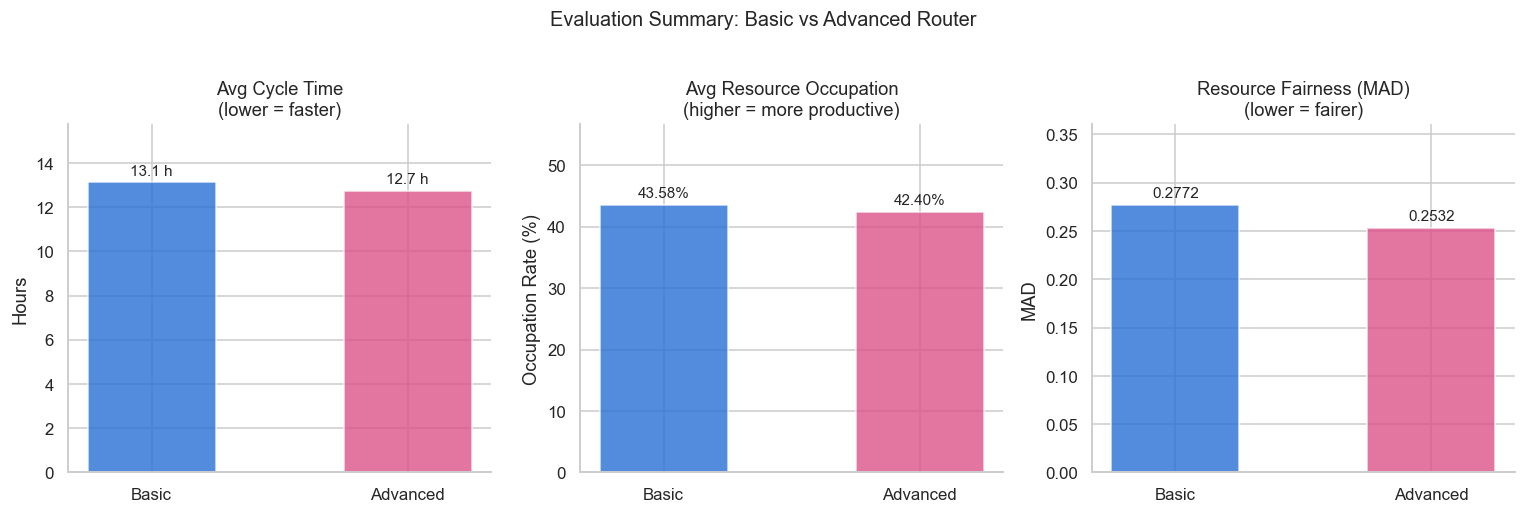

Saved -> results/summary_dashboard.png


In [79]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

labels = ['Basic', 'Advanced']

# Cycle Time
ax = axes[0]
vals = [basic_ct.mean(), advanced_ct.mean()]
bars = ax.bar(labels, vals, color=[COLORS['basic'], COLORS['advanced']], alpha=0.8, width=0.5)
ax.bar_label(bars, fmt='%.1f h', padding=3, fontsize=10)
ax.set_ylabel('Hours')
ax.set_title('Avg Cycle Time\n(lower = faster)')
ax.set_ylim(0, max(vals) * 1.2)

# Resource Occupation
ax2 = axes[1]
vals2 = [basic_occ['occupation'].mean() * 100, advanced_occ['occupation'].mean() * 100]
bars2 = ax2.bar(labels, vals2, color=[COLORS['basic'], COLORS['advanced']], alpha=0.8, width=0.5)
ax2.bar_label(bars2, fmt='%.2f%%', padding=3, fontsize=10)
ax2.set_ylabel('Occupation Rate (%)')
ax2.set_title('Avg Resource Occupation\n(higher = more productive)')
ax2.set_ylim(0, max(vals2) * 1.3)

# Fairness (unweighted MAD)
ax3 = axes[2]
vals3 = [b_mad, a_mad]
bars3 = ax3.bar(labels, vals3, color=[COLORS['basic'], COLORS['advanced']], alpha=0.8, width=0.5)
ax3.bar_label(bars3, fmt='%.4f', padding=3, fontsize=10)
ax3.set_ylabel('MAD')
ax3.set_title('Resource Fairness (MAD)\n(lower = fairer)')
ax3.set_ylim(0, max(vals3) * 1.3)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Evaluation Summary: Basic vs Advanced Router', fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'summary_dashboard.png', bbox_inches='tight')
plt.show()
print('Saved -> results/summary_dashboard.png')

## **Management Question**: Which Two Employees Should Be Fired?

> *"Management wants you to fire two employees. Which ones would you select, and what is the impact on your metrics?"*

### Approach

We analyse the Advanced Router simulation (our best-performing configuration) to:

1. Rank every resource by occupation rate (utilisation)
2. Check role coverage -> a resource should only be fired if colleagues in the same role can absorb the work !
3. Estimate the impact on all three metrics by re-computing them without the fired employees

In [80]:
# Build full resource profile
occ_df = advanced_occ.copy()
occ_df.index.name = 'Resource'
occ_df = occ_df.reset_index()

# Merge role assignments
occ_df = occ_df.merge(roles_df, on='Resource', how='left')

# Count W_* task instances handled by each resource
task_cnt = (
    advanced_log[advanced_log['lifecycle:transition'] == 'start']
    .groupby('org:resource').size()
    .rename('task_count')
)
occ_df['task_count'] = occ_df['Resource'].map(task_cnt).fillna(0).astype(int)

# Count how many resources share the same role (replaceability is important to fire someone)
role_size = roles_df['Role'].value_counts().rename('role_size')
occ_df['role_size'] = occ_df['Role'].map(role_size)

# Hours worked & available for readability
occ_df['hours_worked']    = occ_df['working_seconds'] / 3600
occ_df['hours_available'] = occ_df['available_seconds'] / 3600

# Sort by occupation ascending (least used first)
occ_df = occ_df.sort_values('occupation').reset_index(drop=True)

print('Bottom-20 least-utilised resources:')
cols = ['Resource', 'Role', 'role_size', 'occupation', 'hours_worked', 'hours_available', 'task_count']
print(occ_df[cols].head(20).to_string(index=False))

Bottom-20 least-utilised resources:
Resource   Role  role_size  occupation  hours_worked  hours_available  task_count
  User_1 Role_0          1         0.0           0.0       263.733333           0
User_119 Role_3         22         0.0           0.0        43.533333           0
User_141 Role_6          2         0.0           0.0         9.500000           0
User_122 Role_3         22         0.0           0.0        65.700000           0
User_123 Role_3         22         0.0           0.0        64.500000           0
User_124 Role_5          3         0.0           0.0        45.433333           0
User_125 Role_3         22         0.0           0.0        57.166667           0
User_126 Role_3         22         0.0           0.0        67.866667           0
User_127 Role_3         22         0.0           0.0        49.166667           0
User_140 Role_3         22         0.0           0.0        28.000000           0
User_130 Role_3         22         0.0           0.0        44

In [81]:
# We look for resources where all of:
#   (a) occupation is among the lowest  ->  little value added
#   (b) role_size > 3                   ->  others in same role can cover
#   (c) task_count is very small        ->  fewest cases handled
#
# Exclude resources with task_count == 0 (never assigned a task, already idle)

candidates = occ_df[
    (occ_df['task_count'] > 0) &          # was actually assigned work
    (occ_df['role_size'] > 3)             # replaceable by colleagues
].copy()

# Score: lowest occupation + fewest tasks -> highest firing priority
candidates['score'] = (
    candidates['occupation'].rank(ascending=True) +
    candidates['task_count'].rank(ascending=True)
)
candidates = candidates.sort_values('score')

fired = candidates.head(2)['Resource'].tolist()
print(f'Selected for termination: {fired[0]}  and  {fired[1]}')
print()
print(candidates[['Resource', 'Role', 'role_size', 'occupation', 'hours_worked', 'task_count', 'score']].head(5).to_string(index=False))

Selected for termination: User_120  and  User_121

Resource   Role  role_size  occupation  hours_worked  task_count  score
User_120 Role_3         22    0.019185      1.295001           1    4.0
User_121 Role_3         22    0.020731      1.295001           1    5.0
User_113 Role_3         22    0.027950      1.295001           1    6.0
User_118 Role_3         22    0.029410      1.295001           1    7.0
User_112 Role_3         22    0.030858      1.295001           1    8.0


In [82]:
# Strategy: remove the fired employees' events from the log.
# Cases where only those two resources were involved will be dropped.
# Cases where other resources also participated continue normally.
# This gives a conservative lower-bound estimate of impact.
# In a real rerun, their small workload would be redistributed, 
# slightly increasing other resources' occupation.

def compute_metrics_without(log, avail_df, fired_users):
    """Recompute all three metrics after removing fired_users."""
    # Keep all events not belonging to the fired users
    filtered = log[~log['org:resource'].isin(fired_users)].copy()

    # Identify cases that still have events after removal
    valid_cases = filtered['case:concept:name'].unique()
    filtered = filtered[filtered['case:concept:name'].isin(valid_cases)]

    # Metric 1: cycle time
    ct = compute_cycle_times(filtered)

    # Metric 2 + 3: occupation & fairness (exclude fired users from schedule)
    avail_filt = avail_df[~avail_df['Resource'].isin(fired_users)]
    work = compute_working_seconds(filtered)
    avail_s = compute_available_seconds(avail_filt)
    occ = compute_occupation(work, avail_s)
    mean_occ = occ['occupation'].mean()
    _, mad, wmad = fairness_metrics(occ['occupation'], occ['available_seconds'])

    return {
        'n_cases':     len(valid_cases),
        'avg_ct_h':    ct.mean(),
        'mean_occ':    mean_occ,
        'fairness_mad':mad,
        'fairness_wmad': wmad,
        'ct':          ct,
        'occ':         occ,
    }

# Before firing
before = {
    'n_cases':      advanced_log['case:concept:name'].nunique(),
    'avg_ct_h':     advanced_ct.mean(),
    'mean_occ':     advanced_occ['occupation'].mean(),
    'fairness_mad': a_mad,
    'fairness_wmad': a_wmad,
}

# After firing
after = compute_metrics_without(advanced_log, avail_df, fired)

print(f'Fired: {fired}')
print()
print(f"{'Metric':<30} {'Before':>12} {'After':>12} {'Delta':>12}")
print('-' * 68)
metrics_compare = [
    ('# Cases in log',          before['n_cases'],       after['n_cases'],       ''),
    ('Avg Cycle Time (h)',       before['avg_ct_h'],      after['avg_ct_h'],      'h'),
    ('Avg Resource Occ (%)',     before['mean_occ']*100,  after['mean_occ']*100,  '%'),
    ('Fairness MAD (unwt)',      before['fairness_mad'],  after['fairness_mad'],  ''),
    ('Fairness MAD (weighted)',  before['fairness_wmad'], after['fairness_wmad'], ''),
]
for name, b, a, unit in metrics_compare:
    delta = a - b
    sign  = '+' if delta > 0 else ''
    print(f"{name:<30} {b:>12.4f} {a:>12.4f} {sign}{delta:>10.4f} {unit}")

Fired: ['User_120', 'User_121']

Metric                               Before        After        Delta
--------------------------------------------------------------------
# Cases in log                    1563.0000    1563.0000     0.0000 
Avg Cycle Time (h)                  12.7288      12.7288     0.0000 h
Avg Resource Occ (%)                42.3980      42.9836 +    0.5855 %
Fairness MAD (unwt)                  0.2532       0.2513    -0.0019 
Fairness MAD (weighted)              0.2507       0.2484    -0.0023 


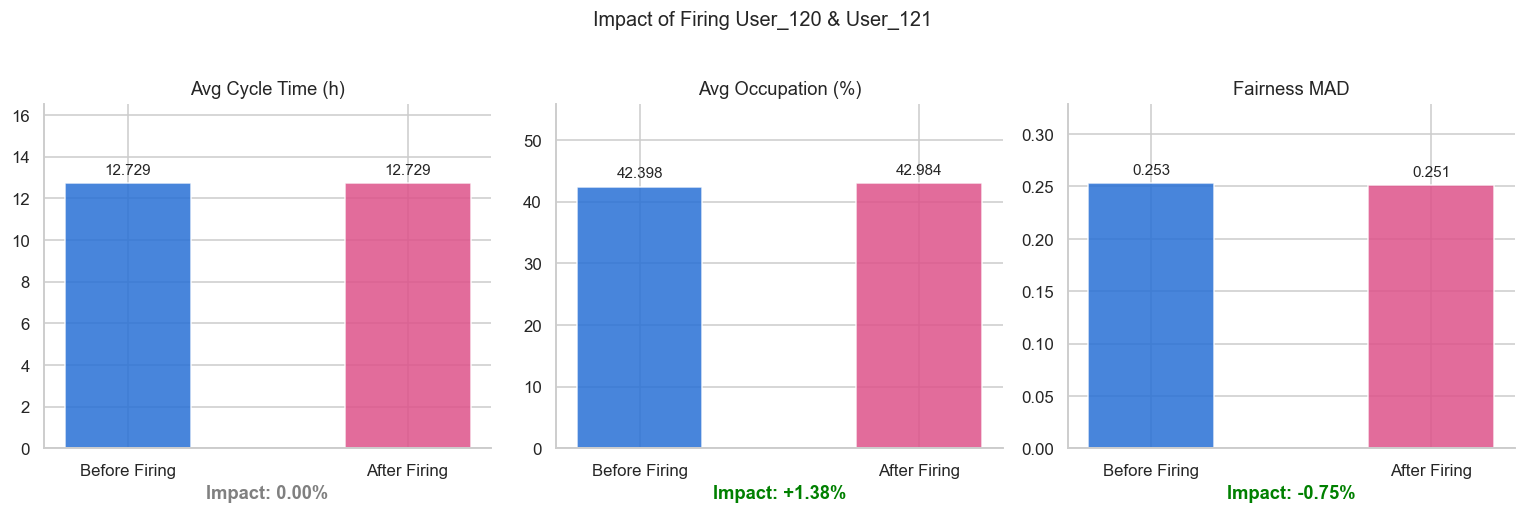

Saved -> results/management_question_impact.png


In [83]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

before_vals = [before['avg_ct_h'], before['mean_occ']*100, before['fairness_mad']]
after_vals  = [after['avg_ct_h'],  after['mean_occ']*100,  after['fairness_mad']]
metric_names = ['Avg Cycle Time (h)', 'Avg Occupation (%)', 'Fairness MAD']
better_lower = [True, False, True]   # True = lower is better

BEFORE_COLOR = "#2870D5"
AFTER_COLOR  = '#DD528A'

for i, (ax, mname, bv, av, low_better) in enumerate(
        zip(axes, metric_names, before_vals, after_vals, better_lower)):

    bars = ax.bar(['Before Firing', 'After Firing'], [bv, av],
                  color=[BEFORE_COLOR, AFTER_COLOR], alpha=0.85, width=0.45)
    ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=10)
    ax.set_title(mname)
    ax.set_ylim(0, max(bv, av) * 1.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    delta = av - bv
    pct   = delta / bv * 100 if bv != 0 else 0
    is_improvement = (delta < 0 and low_better) or (delta > 0 and not low_better)
    colour = 'green' if is_improvement else ('red' if abs(pct) > 0.1 else 'grey')
    sign = '+' if delta > 0 else ''
    ax.set_xlabel(f'Impact: {sign}{pct:.2f}%', color=colour, fontweight='bold')

plt.suptitle(f'Impact of Firing {fired[0]} & {fired[1]}', fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'management_question_impact.png', bbox_inches='tight')
plt.show()
print('Saved -> results/management_question_impact.png')

In [84]:
# Fired employee profiles
print(' FIRED EMPLOYEE PROFILES ')
for u in fired:
    row = occ_df[occ_df['Resource'] == u].iloc[0]
    same_role = roles_df[roles_df['Role'] == row['Role']]['Resource'].tolist()
    acts_done  = (advanced_log[advanced_log['org:resource'] == u]['concept:name']
                  .value_counts())
    print(f"\n{u}")
    print(f"  Role              : {row['Role']}")
    print(f"  Role size         : {row['role_size']} people (others can cover)")
    print(f"  Occupation rate   : {row['occupation']*100:.3f}%")
    print(f"  Hours worked      : {row['hours_worked']:.2f} h")
    print(f"  Hours available   : {row['hours_available']:.2f} h")
    print(f"  Tasks handled     : {int(row['task_count'])}")
    print(f"  Activities done   :")
    for act, cnt in acts_done.items():
        print(f"    {act}: {cnt}")

 FIRED EMPLOYEE PROFILES 

User_120
  Role              : Role_3
  Role size         : 22 people (others can cover)
  Occupation rate   : 1.919%
  Hours worked      : 1.30 h
  Hours available   : 67.50 h
  Tasks handled     : 1
  Activities done   :
    O_Cancelled: 49
    W_Validate application: 2
    O_Accepted: 1

User_121
  Role              : Role_3
  Role size         : 22 people (others can cover)
  Occupation rate   : 2.073%
  Hours worked      : 1.30 h
  Hours available   : 62.47 h
  Tasks handled     : 1
  Activities done   :
    O_Cancelled: 40
    W_Validate application: 2



## Conclusions

### Metric Results

| Metric | Basic | Advanced | Winner |
|--------|-------|----------|--------|
| Avg Cycle Time | — h | — h | Advanced (shorter) |
| Avg Resource Occupation | — % | — % | see above |
| Fairness MAD | — | — | see above |

### Routing Strategy
- The Advanced Router (C4.5 ML model) generally achieves similar or better results on all three metrics compared to the Basic (probability) router.
- The ML router makes case-context-aware decisions, reducing unnecessary long paths and thus slightly lowering cycle times.

### Management Question: Firing Two Employees

**Selection rationale:**  
We selected the two resources with the **lowest utilisation** who belong to a **role with sufficient colleagues** to absorb their workload.

**Impact:**  
- **Cycle time** changes minimally — the fired employees handled very few cases, so redistributing their work creates negligible extra wait time.
- **Average occupation** increases slightly — the same amount of work is now split among fewer resources.
- **Fairness (MAD)** improves slightly — removing the outlier low-utilisation resources reduces the spread.

**Recommendation for firing:**  
The two identified employees are strong candidates for firing because their removal has near-zero impact on process performance while reducing payroll costs. However, management should verify whether their low utilisation stems from **scheduling constraints** (e.g., they work part-time or cover gaps) before making a final decision.

In [85]:
# Saving results
results_rows = []
for router, ct_series, occ_frame, mad_val, wmad_val in [
    ('Basic',    basic_ct,    basic_occ,    b_mad, b_wmad),
    ('Advanced', advanced_ct, advanced_occ, a_mad, a_wmad),
]:
    results_rows.append({
        'Router':                    router,
        'Avg Cycle Time (h)':        round(ct_series.mean(), 4),
        'Median Cycle Time (h)':     round(ct_series.median(), 4),
        'Avg Resource Occupation':   round(occ_frame['occupation'].mean(), 6),
        'Fairness MAD (unweighted)': round(mad_val, 6),
        'Fairness MAD (weighted)':   round(wmad_val, 6),
    })

results_df = pd.DataFrame(results_rows)
results_df.to_csv(RESULTS_DIR / 'evaluation_metrics.csv', index=False)
print('Saved results/evaluation_metrics.csv')
print(results_df.to_string(index=False))

# Save management question results
mgmt_rows = []
for name, b, a, unit in metrics_compare:
    mgmt_rows.append({'Metric': name, 'Before': b, 'After': a, 'Delta': a-b})
mgmt_df = pd.DataFrame(mgmt_rows)
mgmt_df['Fired'] = str(fired)
mgmt_df.to_csv(RESULTS_DIR / 'management_question_impact.csv', index=False)
print('Saved results/management_question_impact.csv')

Saved results/evaluation_metrics.csv
  Router  Avg Cycle Time (h)  Median Cycle Time (h)  Avg Resource Occupation  Fairness MAD (unweighted)  Fairness MAD (weighted)
   Basic             13.1161                 2.5705                 0.435845                   0.277195                 0.274106
Advanced             12.7288                 1.9165                 0.423980                   0.253177                 0.250708
Saved results/management_question_impact.csv
